# Solver Benchmark — 2026-04-22 · ball_rollers_8

Matrices from `ball_rollers/result_10000-2568220-small-12steps` (16 mesh sizes: 9996 – 212201 rows).

- `ball_rollers_8` — 8-way parallel (`OMP_NUM_THREADS=8` for OMP solvers, `mpirun -np 8` for MPI solvers)

**Solvers:** AMGCL (OMP iterative), Eigen::PardisoLDLT (OMP direct), Hypre_mpi (MPI iterative), Trilinos (MPI iterative).

Plot: **elapse time vs matrix size (rows)** on log–log axes, with log–linear fit lines to show scaling slope.

In [11]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

sys.path.insert(0, '/u/1/chenyang/benchmark/analysis')
import libs.parser; importlib.reload(libs.parser)
from libs.parser import parse_log_file

SOLVER_COLORS = {
    "AMGCL":              "#d62728",
    "Eigen::PardisoLDLT": "#1f77b4",
    "Hypre_mpi":          "#2ca02c",
    "Trilinos":           "#ff7f0e",
}
# Longest prefix first so "Eigen::PardisoLDLT" matches before "Eigen::"
SOLVER_PREFIXES = sorted(SOLVER_COLORS.keys(), key=len, reverse=True)

DATA_SOURCE_NOTE = "Matrices: PolyFEM forced PSD  ·  mesh: ball_rollers/result_10000-2568220-small-12steps"


def load_all_logs(log_dir):
    """Parse every *.log under log_dir, return DataFrame(solver, mat_sz, nnz, elapse_time, num_iterations)."""
    rows = []
    for fname in sorted(os.listdir(log_dir)):
        if not fname.endswith(".log"):
            continue
        solver = None
        for prefix in SOLVER_PREFIXES:
            if fname.startswith(prefix + "_"):
                solver = prefix
                break
        if solver is None:
            continue
        try:
            entries = parse_log_file(os.path.join(log_dir, fname), solver)
        except Exception as ex:
            print(f"Skipping {fname}: {ex}")
            continue
        for e in entries:
            if e.get("mat_sz") and e.get("elapse_time"):
                rows.append({
                    "solver":         solver,
                    "mat_sz":         e["mat_sz"],
                    "nnz":            e.get("nnz"),
                    "elapse_time":    e["elapse_time"],
                    "num_iterations": e.get("num_iterations"),
                })
    return pd.DataFrame(rows)


def plot_time_vs_mat_sz(df, title, figsize=(10, 6)):
    """Scatter elapse_time vs mat_sz for each solver + log-log linear fit on per-mat_sz means."""
    fig, ax = plt.subplots(figsize=figsize)
    for solver in SOLVER_PREFIXES:
        g = df[df["solver"] == solver]
        if g.empty:
            continue
        color = SOLVER_COLORS[solver]
        ax.scatter(g["mat_sz"], g["elapse_time"], s=16, alpha=0.5, color=color,
                   label=f"{solver} (n={len(g)})")

        g_mean = g.groupby("mat_sz")["elapse_time"].mean().reset_index().sort_values("mat_sz")
        if len(g_mean) >= 3:
            log_x = np.log10(g_mean["mat_sz"].values)
            log_y = np.log10(g_mean["elapse_time"].values)
            slope, intercept = np.polyfit(log_x, log_y, 1)
            x_fit = np.logspace(log_x.min(), log_x.max(), 200)
            y_fit = 10 ** (slope * np.log10(x_fit) + intercept)
            ax.plot(x_fit, y_fit, "--", color=color, linewidth=1.5, alpha=0.8,
                    label=f"  fit (slope={slope:.2f}, on means)")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Matrix Size (rows, log scale)", fontsize=12)
    ax.set_ylabel("Elapse Time (s, log scale)", fontsize=12)
    full_title = f"{title}\n{DATA_SOURCE_NOTE}  ·  fit lines = log-linear over mean elapse_time per mat_sz"
    ax.set_title(full_title, fontsize=11)
    ax.legend(fontsize=9, loc="upper left", ncol=2)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    return fig, ax


LOG_DIR = ('/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/'
           '2026-4-22/result_10000-2568220-small-12steps/ball_rollers_8')
print(f"Log dir: {LOG_DIR}")
print(f"Files:   {len(os.listdir(LOG_DIR))}")

Log dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-22/result_10000-2568220-small-12steps/ball_rollers_8
Files:   64


## Elapse time vs matrix size — `ball_rollers_8`

mat size exception: index 0 is out of bounds for axis 0 with size 0
nnz exception: index 2 is out of bounds for axis 0 with size 0
mat size exception: index 0 is out of bounds for axis 0 with size 0
nnz exception: index 2 is out of bounds for axis 0 with size 0
mat size exception: index 0 is out of bounds for axis 0 with size 0
nnz exception: index 2 is out of bounds for axis 0 with size 0
mat size exception: index 0 is out of bounds for axis 0 with size 0
nnz exception: index 2 is out of bounds for axis 0 with size 0
mat size exception: index 0 is out of bounds for axis 0 with size 0
nnz exception: index 2 is out of bounds for axis 0 with size 0
mat size exception: index 0 is out of bounds for axis 0 with size 0
nnz exception: index 2 is out of bounds for axis 0 with size 0
mat size exception: index 0 is out of bounds for axis 0 with size 0
nnz exception: index 2 is out of bounds for axis 0 with size 0
mat size exception: index 0 is out of bounds for axis 0 with size 0
nnz exception: 

Skipping Trilinos_109344.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-22/result_10000-2568220-small-12steps/ball_rollers_8/Trilinos_109344.log
Skipping Trilinos_129097.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-22/result_10000-2568220-small-12steps/ball_rollers_8/Trilinos_129097.log
Skipping Trilinos_151276.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-22/result_10000-2568220-small-12steps/ball_rollers_8/Trilinos_151276.log
Skipping Trilinos_169997.log: #[EXPBEGIN] #[EXPEND] mismatches, unknown error formats. Error dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-22/result_10000-2568220-small-12steps/ball_rollers_8/Trilinos_169997.log
Skipping Tri

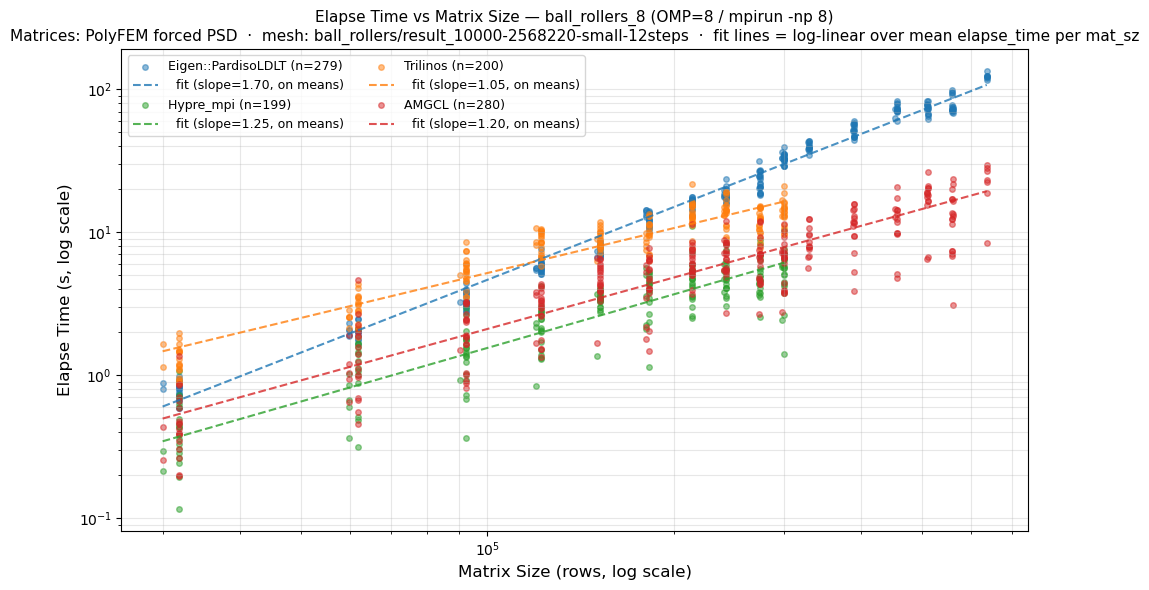

In [12]:
df8 = load_all_logs(LOG_DIR)
print(f"ball_rollers_8: {len(df8)} entries")
print(df8.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'elapse_time': 'mean'}))

fig, ax = plot_time_vs_mat_sz(df8, 'Elapse Time vs Matrix Size — ball_rollers_8 (OMP=8 / mpirun -np 8)')
plt.show()

## Extrapolate log–log fit to `mat_sz = 1e7`

Current dataset only reaches `mat_sz ≈ 2.1e5`. To compare against group 2 of
`analysis-2026-4-8.ipynb` (which goes to `mat_sz ≈ 2.6e6`), extend each solver's
log–linear fit line out to **`mat_sz = 1e7`**.

**Caveat:** extrapolating ~2 orders of magnitude beyond the fit range. Actual
runtime at 1e7 rows will very likely diverge from the fit — memory pressure, NUMA
effects, direct-solver superlinear scaling, and AMG convergence degradation all
kick in at large sizes. Treat the extrapolated segment as a *naive projection*
from the current scaling regime, not a prediction.

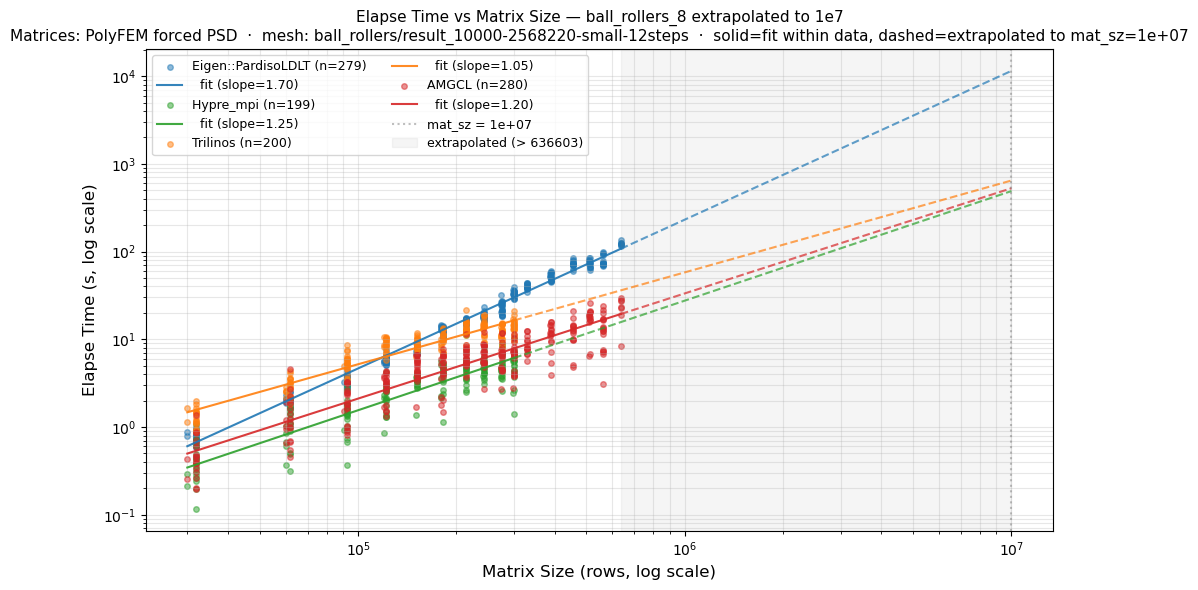


Projected elapse_time at mat_sz = 1e7 (naive log-linear extrapolation):
  Hypre_mpi             slope=1.25  t(1e7) ≈      489.3 s  (8.2 min)
  AMGCL                 slope=1.20  t(1e7) ≈      527.0 s  (8.8 min)
  Trilinos              slope=1.05  t(1e7) ≈      645.5 s  (10.8 min)
  Eigen::PardisoLDLT    slope=1.70  t(1e7) ≈    11478.7 s  (191.3 min)


In [13]:
def plot_time_vs_mat_sz_extrapolate(df, title, x_extrap=1e7, figsize=(10, 6)):
    """Scatter data + log-linear fit extended to x_extrap.
    Solid segment covers the observed range; dashed segment is the extrapolation."""
    fig, ax = plt.subplots(figsize=figsize)
    fits = []
    for solver in SOLVER_PREFIXES:
        g = df[df['solver'] == solver]
        if g.empty:
            continue
        color = SOLVER_COLORS[solver]
        ax.scatter(g['mat_sz'], g['elapse_time'], s=16, alpha=0.5, color=color,
                   label=f'{solver} (n={len(g)})')

        g_mean = g.groupby('mat_sz')['elapse_time'].mean().reset_index().sort_values('mat_sz')
        if len(g_mean) < 3:
            continue
        log_x = np.log10(g_mean['mat_sz'].values)
        log_y = np.log10(g_mean['elapse_time'].values)
        slope, intercept = np.polyfit(log_x, log_y, 1)

        # Solid: within observed range
        x_in = np.logspace(log_x.min(), log_x.max(), 120)
        y_in = 10 ** (slope * np.log10(x_in) + intercept)
        ax.plot(x_in, y_in, '-', color=color, linewidth=1.5, alpha=0.9,
                label=f'  fit (slope={slope:.2f})')

        # Dashed: extrapolated region
        if x_extrap > 10 ** log_x.max():
            x_out = np.logspace(log_x.max(), np.log10(x_extrap), 120)
            y_out = 10 ** (slope * np.log10(x_out) + intercept)
            ax.plot(x_out, y_out, '--', color=color, linewidth=1.5, alpha=0.7)
            y_at_extrap = 10 ** (slope * np.log10(x_extrap) + intercept)
            fits.append((solver, slope, y_at_extrap))

    ax.axvline(x_extrap, color='grey', linestyle=':', alpha=0.5,
               label=f'mat_sz = {x_extrap:.0e}')
    # Shade the extrapolated region for clarity
    x_obs_max = df['mat_sz'].max()
    ax.axvspan(x_obs_max, x_extrap, color='grey', alpha=0.08,
               label=f'extrapolated (> {x_obs_max:.0f})')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
    ax.set_ylabel('Elapse Time (s, log scale)', fontsize=12)
    full_title = (f'{title}\n{DATA_SOURCE_NOTE}  ·  solid=fit within data, dashed=extrapolated to '
                  f'mat_sz={x_extrap:.0e}')
    ax.set_title(full_title, fontsize=11)
    ax.legend(fontsize=9, loc='upper left', ncol=2)
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    return fig, ax, fits


fig, ax, fits = plot_time_vs_mat_sz_extrapolate(
    df8,
    'Elapse Time vs Matrix Size — ball_rollers_8 extrapolated to 1e7',
    x_extrap=1e7,
)
plt.show()

print('\nProjected elapse_time at mat_sz = 1e7 (naive log-linear extrapolation):')
for solver, slope, t in sorted(fits, key=lambda x: x[2]):
    print(f'  {solver:20}  slope={slope:.2f}  t(1e7) ≈ {t:10.1f} s  ({t/60:.1f} min)')

## Solve time vs simulation step / newton iteration — `9996` full run

Two logs from a long simulation on the 9996-row mesh:

- `9996-full-run-test` — steps 1–34 (primary)
- `9996-full-run-test-1` — steps 31–39 (continuation; overlap with primary resolved by keeping the primary)

X-axis tick is `step-iter` (outer-inner). Vertical dividers mark simulation-step
boundaries. The goal is to see how **`elapse_time` varies across newton iterations
within a step and across steps** — later steps tend to be harder (more contacts,
denser stiffness structure).

log1: 1825 entries, steps 1-34
log2: 1011 entries, steps 31-40
merged (primary wins): 2455 entries, steps 1-40
source distribution in merged: {'log1 (primary)': 1825, 'log2 (continuation)': 630}


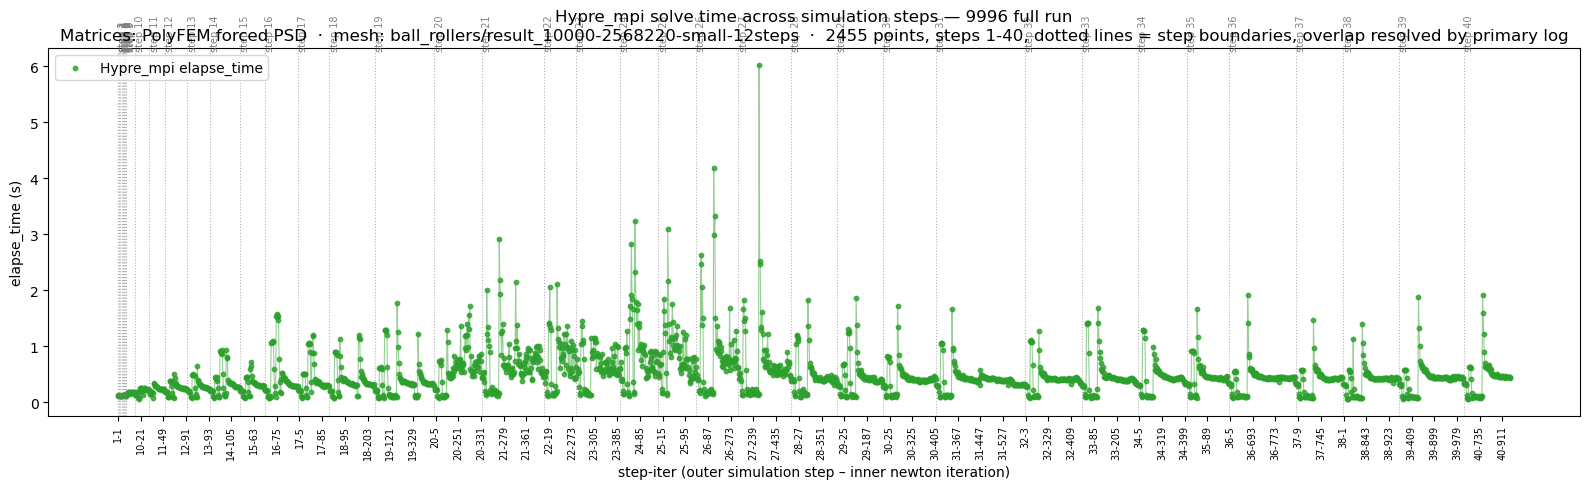

In [14]:
import re

LOG1 = ('/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/'
        '2026-4-22/9996-full-run-test/ball_rollers_8/Hypre_mpi_9996.log')
LOG2 = ('/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/'
        '2026-4-22/9996-full-run-test-1/ball_rollers_8/Hypre_mpi_9996.log')


def _parse_to_df(lp, source_tag):
    rows = []
    for e in parse_log_file(lp, 'Hypre_mpi'):
        m = re.search(r'/(\d+)_(\d+)_A\.bin$', e.get('bin_A') or '')
        if not m:
            continue
        rows.append({
            'step': int(m.group(1)),
            'iter': int(m.group(2)),
            'elapse_time':    e.get('elapse_time'),
            'solve':          e.get('solve'),
            'factorize':      e.get('factorize'),
            'num_iterations': e.get('num_iterations'),
            'source':         source_tag,
        })
    return pd.DataFrame(rows)


df_a = _parse_to_df(LOG1, 'log1 (primary)')
df_b = _parse_to_df(LOG2, 'log2 (continuation)')
# First log wins on overlap
merged = (pd.concat([df_a, df_b])
            .drop_duplicates(subset=['step', 'iter'], keep='first')
            .sort_values(['step', 'iter'])
            .reset_index(drop=True))
print(f'log1: {len(df_a)} entries, steps {df_a.step.min()}-{df_a.step.max()}')
print(f'log2: {len(df_b)} entries, steps {df_b.step.min()}-{df_b.step.max()}')
print(f'merged (primary wins): {len(merged)} entries, steps {merged.step.min()}-{merged.step.max()}')
print(f'source distribution in merged: {merged.source.value_counts().to_dict()}')

# Build integer x-index, tick labels "step-iter", and step-boundary positions.
merged['x'] = range(len(merged))
step_start = merged.groupby('step')['x'].min().to_dict()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(merged['x'], merged['elapse_time'], '-', color='#2ca02c', linewidth=0.8, alpha=0.5)
ax.scatter(merged['x'], merged['elapse_time'], s=10, color='#2ca02c', alpha=0.8, label='Hypre_mpi elapse_time')

# Vertical dividers between steps (draw at the start of each step after the first)
for step in sorted(step_start.keys())[1:]:
    ax.axvline(step_start[step] - 0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)

# Step labels above the plot
ymax = merged['elapse_time'].max()
for step, x0 in step_start.items():
    ax.text(x0, ymax * 1.04, f'step {step}', fontsize=7, rotation=90,
            ha='left', va='bottom', color='grey')

# X-ticks: show every K-th label to avoid clutter
stride = max(1, len(merged) // 60)
tick_pos = list(merged['x'][::stride])
tick_lbl = [f"{merged['step'].iat[i]}-{merged['iter'].iat[i]}" for i in range(0, len(merged), stride)]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, rotation=90, fontsize=7)

ax.set_xlabel('step-iter (outer simulation step – inner newton iteration)')
ax.set_ylabel('elapse_time (s)')
ax.set_title(f'Hypre_mpi solve time across simulation steps — 9996 full run\n'
             f'{DATA_SOURCE_NOTE}  ·  {len(merged)} points, steps {merged.step.min()}-{merged.step.max()}, '
             f'dotted lines = step boundaries, overlap resolved by primary log')
# ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Same axes — but y = `num_iterations`

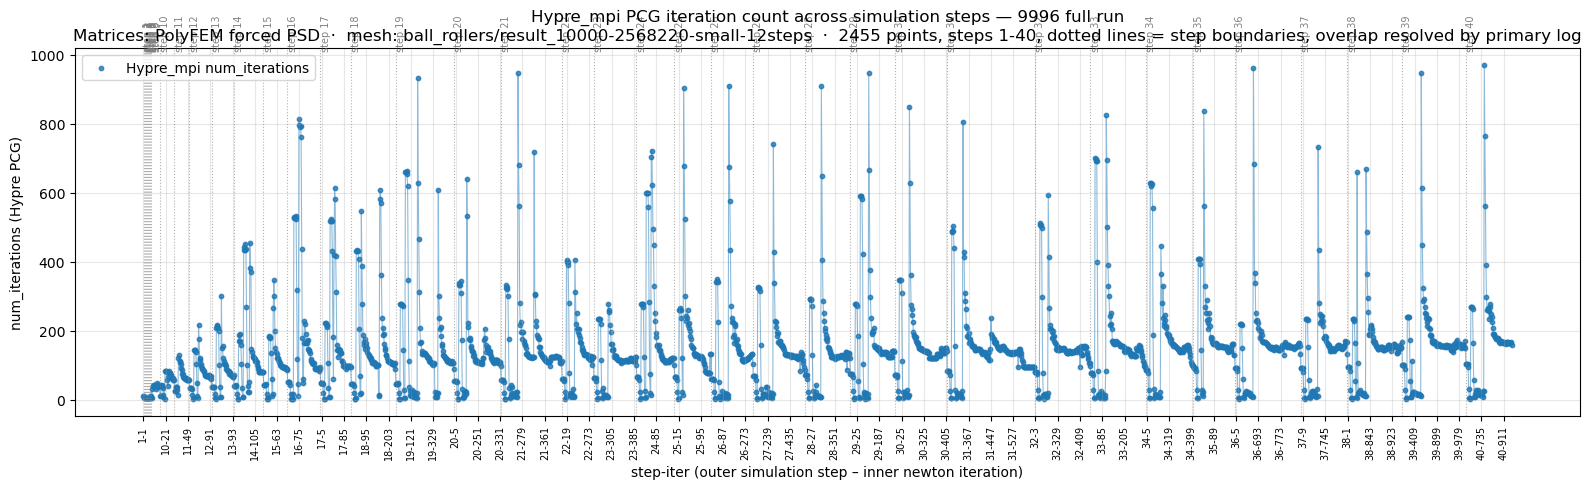

In [15]:
# Reuse `merged` from the previous cell; just swap the y-axis.
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(merged['x'], merged['num_iterations'], '-', color='#1f77b4', linewidth=0.8, alpha=0.5)
ax.scatter(merged['x'], merged['num_iterations'], s=10, color='#1f77b4', alpha=0.8,
           label='Hypre_mpi num_iterations')

for step in sorted(step_start.keys())[1:]:
    ax.axvline(step_start[step] - 0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)

ymax = merged['num_iterations'].max()
for step, x0 in step_start.items():
    ax.text(x0, ymax * 1.04, f'step {step}', fontsize=7, rotation=90,
            ha='left', va='bottom', color='grey')

stride = max(1, len(merged) // 60)
tick_pos = list(merged['x'][::stride])
tick_lbl = [f"{merged['step'].iat[i]}-{merged['iter'].iat[i]}" for i in range(0, len(merged), stride)]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, rotation=90, fontsize=7)

ax.set_xlabel('step-iter (outer simulation step – inner newton iteration)')
ax.set_ylabel('num_iterations (Hypre PCG)')
ax.set_title(f'Hypre_mpi PCG iteration count across simulation steps — 9996 full run\n'
             f'{DATA_SOURCE_NOTE}  ·  {len(merged)} points, steps {merged.step.min()}-{merged.step.max()}, '
             f'dotted lines = step boundaries, overlap resolved by primary log')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Storage report — `/mnt/hdd1` is full

| | size |
|---|---|
| Filesystem `/mnt/hdd1` total | **15 TB** |
| Used | 14 TB (**100 %**, 0 available) |
| My `/mnt/hdd1/chenyang/` | **1.2 TB** |
| — `benchmark_data/larger_matrix_exp/golf-ball/` | 169 GB |
| — `benchmark_data/larger_matrix_exp/ball_rollers/` | 1003 GB (~1 TB) |

My share is ~8 % of the disk; the remaining ~13 TB belongs to other users.
The disk is at **100 % used** with 0 bytes available, which is why new dumps/benchmarks
fail and existing 0-byte placeholder `.bin` files get left behind.